# Análise exploratória com foco no desbalanceamento (Passo 5 do guia)

Este notebook espera o arquivo `data/raw/creditcard.csv` (dataset Credit Card Fraud Detection, ULB/Worldline, Kaggle). Baixe o dataset e salve-o nesse caminho antes de rodar as células abaixo.

In [1]:
import sys
from pathlib import Path

# adiciona a raiz do projeto ao sys.path: o kernel roda com cwd em
# notebooks/, e o pacote src/ fica um nível acima
if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.ingestion.load_data import load_raw_transactions

df = load_raw_transactions()
df.shape

(284807, 31)

## Proporção entre as duas classes

Essa proporção guia todas as decisões metodológicas seguintes (estratégia de balanceamento, métricas de avaliação).

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


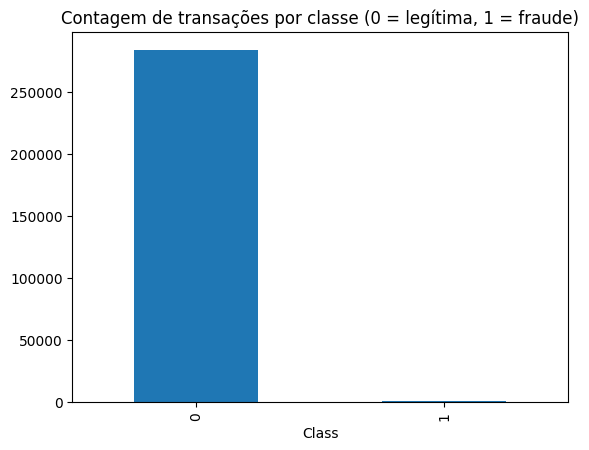

In [2]:
class_counts = df["Class"].value_counts()
class_fraction = df["Class"].value_counts(normalize=True)
print(class_counts)
print(class_fraction)

class_counts.plot(kind="bar", title="Contagem de transações por classe (0 = legítima, 1 = fraude)")
plt.show()

## Distribuição do valor da transação por classe

Fraudes costumam se concentrar em faixas de valor específicas, mesmo em um dataset anonimizado como este.

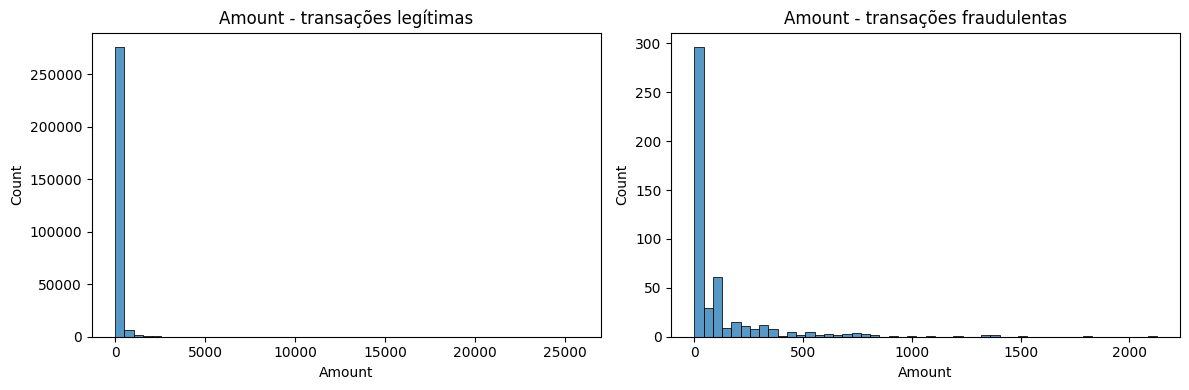

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.loc[df["Class"] == 0, "Amount"], bins=50, ax=axes[0])
axes[0].set_title("Amount - transações legítimas")
sns.histplot(df.loc[df["Class"] == 1, "Amount"], bins=50, ax=axes[1])
axes[1].set_title("Amount - transações fraudulentas")
plt.tight_layout()
plt.show()

df.groupby("Class")["Amount"].describe()

## Taxa de fraude ao longo do tempo

Verifica se a taxa de fraude varia ao longo das duas janelas de 24 horas cobertas pelo dataset.

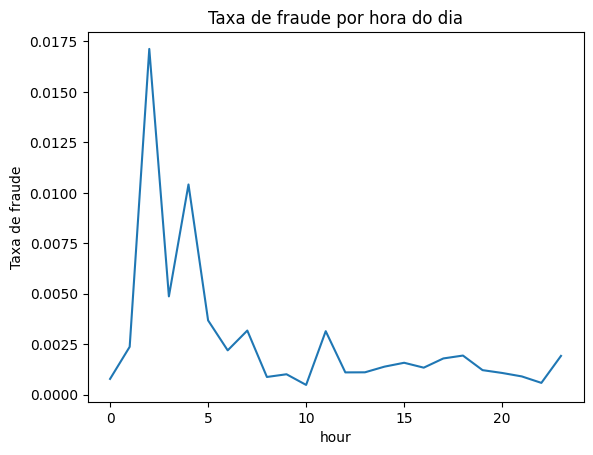

In [4]:
df["hour"] = (df["Time"] // 3600) % 24
fraud_rate_by_hour = df.groupby("hour")["Class"].mean()

fraud_rate_by_hour.plot(title="Taxa de fraude por hora do dia")
plt.ylabel("Taxa de fraude")
plt.show()

## Separação das distribuições de V1..V28 entre as duas classes

Como V1..V28 são componentes principais, uma matriz de correlação entre elas é pouco informativa por construção (componentes principais são desenhados para serem não correlacionados). É mais produtivo observar quais componentes mostram maior diferença de distribuição entre fraude e não fraude.

In [5]:
v_columns = [f"V{i}" for i in range(1, 29)]

mean_diff = (
    df.loc[df["Class"] == 1, v_columns].mean() - df.loc[df["Class"] == 0, v_columns].mean()
).abs().sort_values(ascending=False)

mean_diff.head(10)

V3     7.045452
V14    6.983787
V17    6.677371
V12    6.270225
V10    5.686707
V7     5.578368
V1     4.780206
V4     4.549889
V16    4.147110
V11    3.806749
dtype: float64

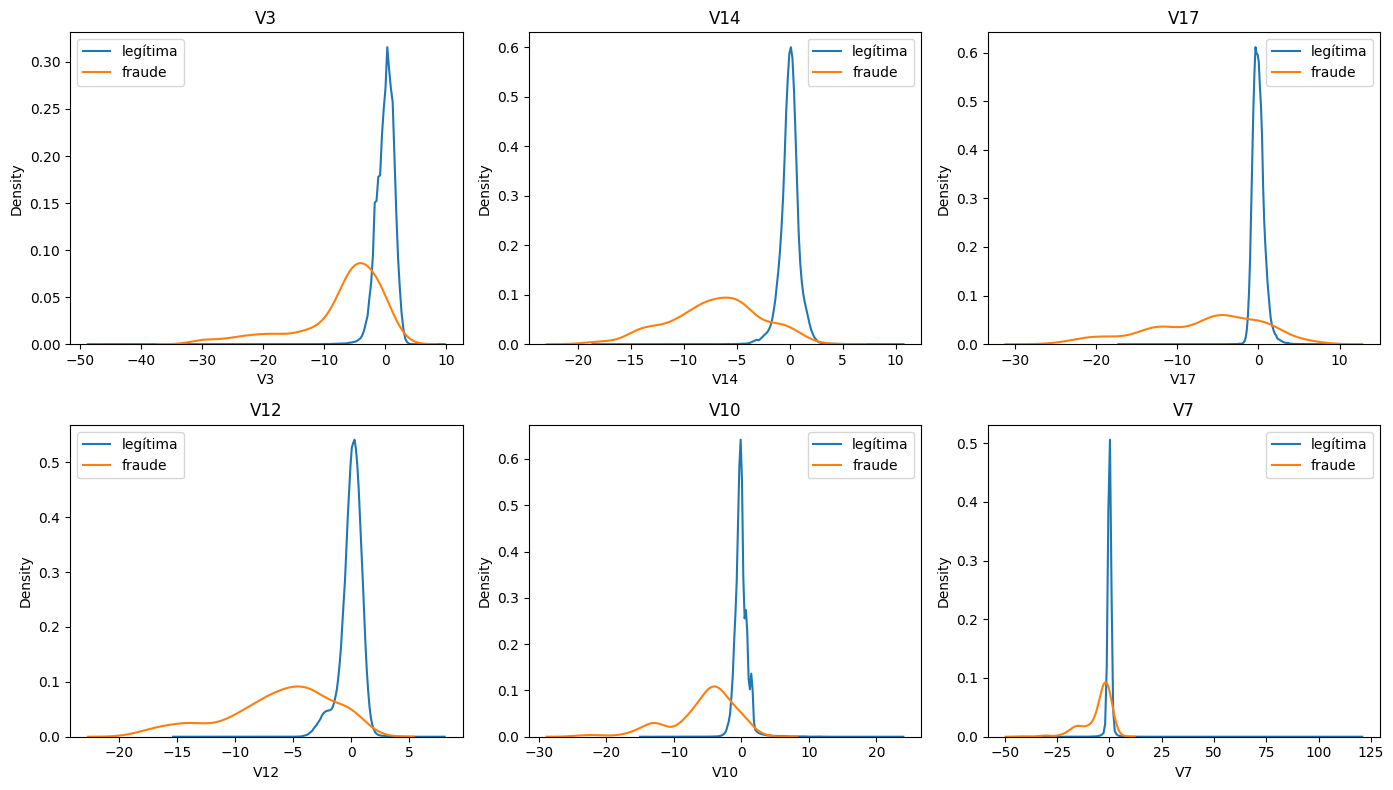

In [6]:
top_components = mean_diff.head(6).index
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), top_components):
    sns.kdeplot(df.loc[df["Class"] == 0, col], label="legítima", ax=ax)
    sns.kdeplot(df.loc[df["Class"] == 1, col], label="fraude", ax=ax)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()